In [1]:
# Cell 1: Imports and setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import cv2
from pathlib import Path
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings("ignore")

# TensorFlow imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, LearningRateScheduler, 
                                      ModelCheckpoint, TensorBoard, CSVLogger)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, 
                                   BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# VS Code specific
from IPython.display import display
import ipywidgets as widgets

# Set random seed
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Cell 2: Dataset loading function
def load_dataset_manual():
    """
    Manual dataset loader for VS Code without Google Drive dependency
    Returns: DataFrame with 'filepaths' and 'labels' columns
    """
    base_path = r"E:\\INTERNSHIP\\project\\The IQ-OTHNCCD lung cancer dataset"

    # Initialize lists
    filepaths = []
    labels = []
    corrupted_files = []

    categories = {
        'Bengin cases': 'Benign',
        'Malignant cases': 'Malignant',
        'Normal cases': 'Normal'
    }

    for category_folder, label in categories.items():
        category_path = os.path.join(base_path, category_folder)

        if not os.path.exists(category_path):
            print(f"Warning: {category_path} not found. Skipping...")
            continue

        print(f"Processing {label} images...")

        for filename in tqdm(os.listdir(category_path)):
            filepath = os.path.join(category_path, filename)

            try:
                with Image.open(filepath) as img:
                    img.verify()
                filepaths.append(filepath)
                labels.append(label)
            except (IOError, OSError):
                corrupted_files.append(filepath)

    df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})
    print("\nDataset loaded successfully!")
    print(f"Total images: {len(df)}")
    print(f"Corrupted files: {len(corrupted_files)}")

    if corrupted_files:
        with open("corrupted_files.txt", "w") as f:
            f.write("\n".join(corrupted_files))

    print("\nClass distribution:")
    print(df['labels'].value_counts())

    return df

In [3]:
# Cell 3: Load and display dataset
df = load_dataset_manual()
df.head()

Processing Benign images...


100%|██████████| 120/120 [00:00<00:00, 2238.89it/s]


Processing Malignant images...


100%|██████████| 561/561 [00:00<00:00, 2698.85it/s]


Processing Normal images...


100%|██████████| 416/416 [00:00<00:00, 2980.50it/s]


Dataset loaded successfully!
Total images: 1097
Corrupted files: 0

Class distribution:
labels
Malignant    561
Normal       416
Benign       120
Name: count, dtype: int64


,filepaths,labels
0,E:\\INTERNSHIP\\project\\The IQ-OTHNCCD lung c...,Benign
1,E:\\INTERNSHIP\\project\\The IQ-OTHNCCD lung c...,Benign
2,E:\\INTERNSHIP\\project\\The IQ-OTHNCCD lung c...,Benign
3,E:\\INTERNSHIP\\project\\The IQ-OTHNCCD lung c...,Benign
4,E:\\INTERNSHIP\\project\\The IQ-OTHNCCD lung c...,Benign


In [4]:
# Cell 4: Train/validation/test split
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['labels'], random_state=SEED)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['labels'], random_state=SEED)

print(f"Train: {train_df.shape[0]} samples")
print(f"Validation: {val_df.shape[0]} samples")
print(f"Test: {test_df.shape[0]} samples")

Train: 877 samples
Validation: 110 samples
Test: 110 samples


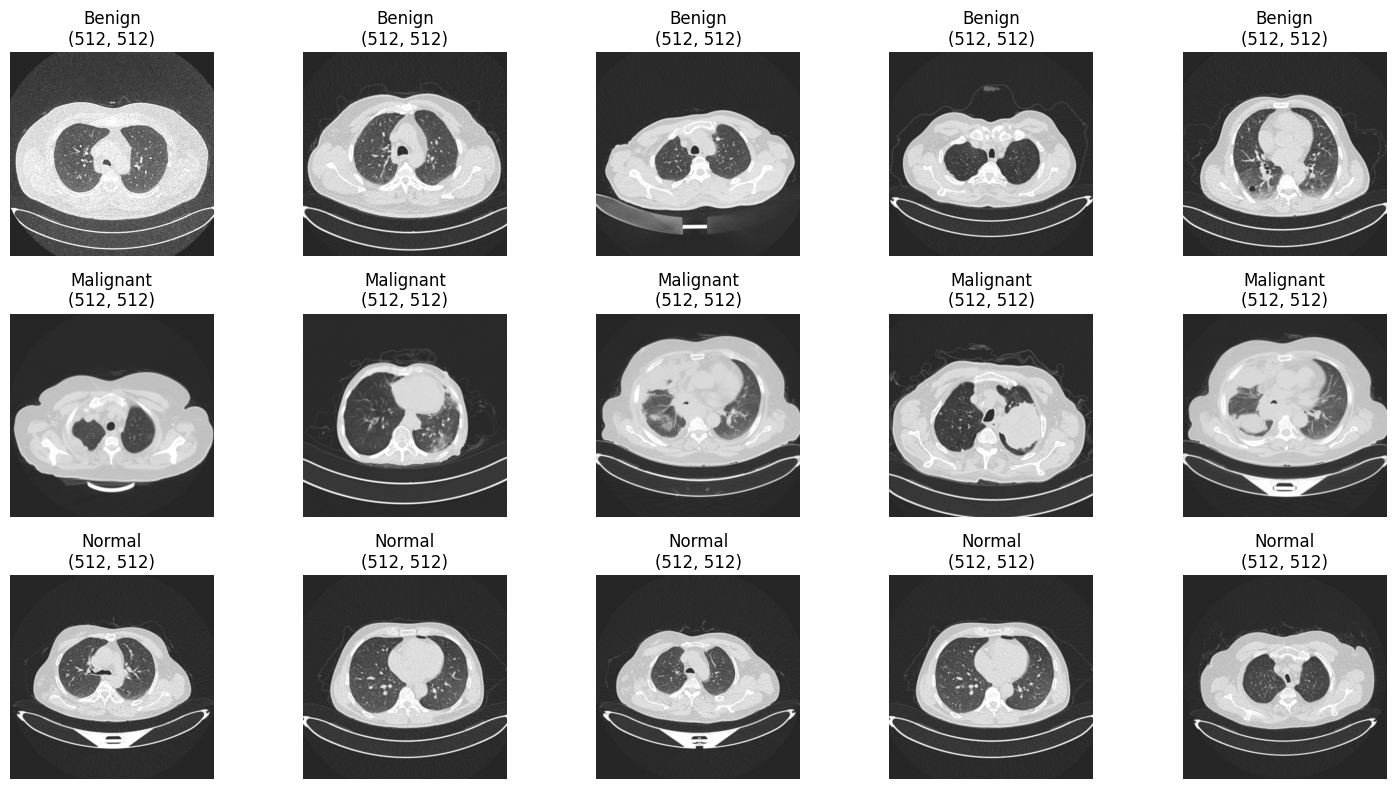

In [5]:
# Cell 5: Data visualization
def show_sample_images(df, n=5):
    plt.figure(figsize=(15, 8))
    for i, (label, group) in enumerate(df.groupby('labels')):
        for j, (_, row) in enumerate(group.sample(n, random_state=SEED).iterrows()):
            ax = plt.subplot(3, n, i*n + j + 1)
            img = plt.imread(row['filepaths'])
            plt.imshow(img)
            plt.title(f"{label}\n{img.shape[:2]}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(train_df)

In [6]:
# Cell 6: Data augmentation and generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("\nClass names:", class_names)

Found 877 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.
Found 110 validated image filenames belonging to 3 classes.

Class names: ['Benign', 'Malignant', 'Normal']


In [7]:
# Cell 7: Model architecture
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers

# Build custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,051,075 (11.64 MB)

 Trainable params: 790,531 (3.02 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [8]:
# Cell 8: Callbacks setup
os.makedirs("logs", exist_ok=True)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_loss'),
    CSVLogger("logs/training_log.csv"),
    TensorBoard(log_dir="logs/tensorboard")
]

In [9]:
# Cell 9: Model training
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.5656 - loss: 1.0498

28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 688ms/step - accuracy: 0.5690 - loss: 1.0432 - val_accuracy: 0.8273 - val_loss: 0.5197
Epoch 2/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.8051 - loss: 0.5246

28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 739ms/step - accuracy: 0.8052 - loss: 0.5245 - val_accuracy: 0.8727 - val_loss: 0.4137
Epoch 3/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.8244 - loss: 0.4565

28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 598ms/step - accuracy: 0.8245 - loss: 0.4564 - val_accuracy: 0.9000 - val_loss: 0.3585
Epoch 4/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.8385 - loss: 0.4399

28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 608ms/step - accuracy: 0.8387 - loss: 0.4389 - val_accuracy: 0.8909 - val_loss: 0.3269
Epoch 5/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.8441 - loss: 0.3919

...

28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 592ms/step - accuracy: 0.9176 - loss: 0.2131 - val_accuracy: 0.8818 - val_loss: 0.2252
Epoch 19/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9095 - loss: 0.2393

28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 590ms/step - accuracy: 0.9097 - loss: 0.2387 - val_accuracy: 0.9000 - val_loss: 0.2231
Epoch 20/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.9066 - loss: 0.2058

28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 575ms/step - accuracy: 0.9064 - loss: 0.2060 - val_accuracy: 0.8909 - val_loss: 0.2175
Epoch 21/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 609ms/step - accuracy: 0.9145 - loss: 0.2158 - val_accuracy: 0.8909 - val_loss: 0.2317
Epoch 22/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.9217 - loss: 0.1996

28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 581ms/step - accuracy: 0.9216 - loss: 0.1999 - val_accuracy: 0.8909 - val_loss: 0.2074
Epoch 23/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 566ms/step - accuracy: 0.9116 - loss: 0.2168 - val_accuracy: 0.9000 - val_loss: 0.2080
Epoch 24/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.9098 - loss: 0.2126

28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 585ms/step - accuracy: 0.9096 - loss: 0.2130 - val_accuracy: 0.8909 - val_loss: 0.1937
Epoch 25/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 614ms/step - accuracy: 0.9139 - loss: 0.1959 - val_accuracy: 0.9000 - val_loss: 0.2102


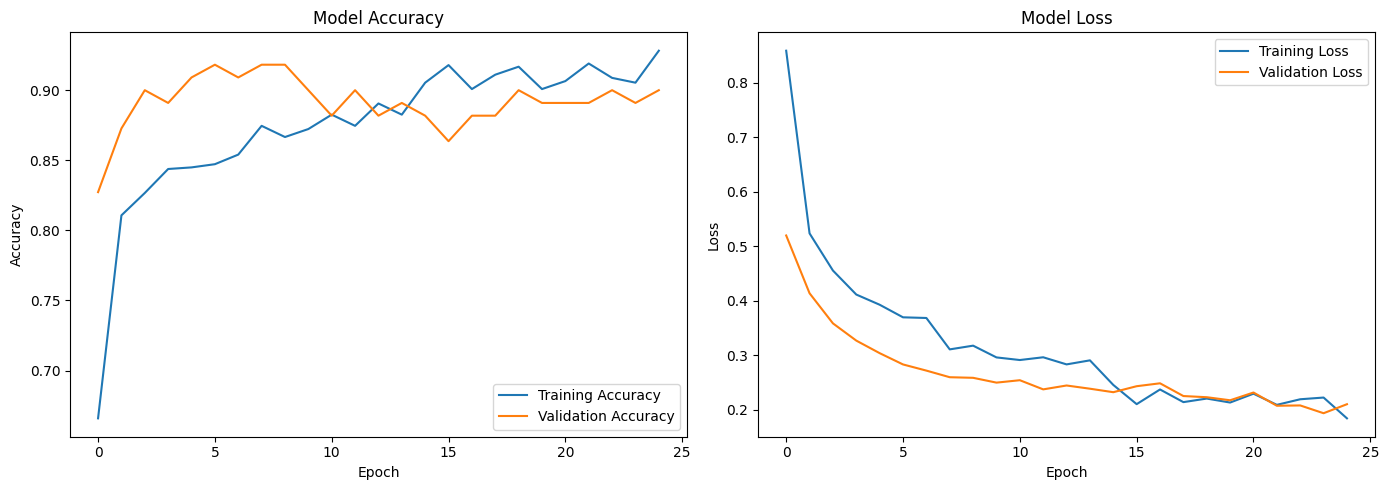

In [10]:
# Cell 10: Plot training history
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [11]:
# Cell 11: Test evaluation
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.8860 - loss: 0.2315
Test Accuracy: 90.00%


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 582ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.53      0.83      0.65        12
   Malignant       1.00      1.00      1.00        57
      Normal       0.94      0.78      0.85        41

    accuracy                           0.90       110
   macro avg       0.82      0.87      0.83       110
weighted avg       0.93      0.90      0.91       110



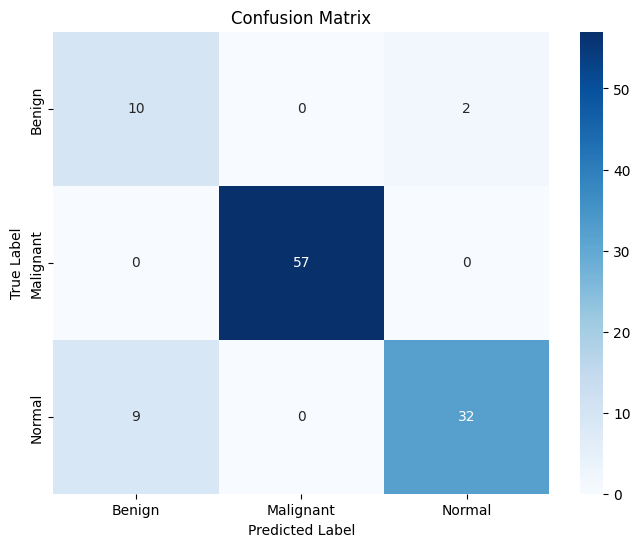

In [12]:
# Cell 12: Predictions and metrics
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [13]:
import pickle

# Save model as pickle
with open('lungcan.pkl', 'wb') as f:
    pickle.dump(model, f)
